# Driver Drowsiness & Distraction Detection — End-to-End Run
### Team 3 | Dataset: YawDD | Phone: YOLOv8n COCO

**Before starting:** `Runtime → Change runtime type → T4 GPU`

| Cells | What happens |
|-------|--------------|
| 1–2   | Install packages, mount Drive |
| 3–4   | Kaggle API, download YawDD |
| 5–7   | Extract frames from videos, EDA, split |
| 8–9   | Initialize all 4 detectors + pipeline |
| 10    | Sanity check on YawDD frames |
| 11    | Load YOLOv8n COCO (phone detection) |
| 12    | Upload test video + run full inference |
| 13–16 | Metrics dashboard, ablation, confusion matrix, FPS benchmark |
| 17    | **Save all models + config for Streamlit** |
| 18–19 | Download bundle + final summary |


---
## STEP 1 — Setup

In [1]:
# CELL 1 — Install packages + verify GPU
import subprocess
r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                   capture_output=True, text=True)
print('GPU:', r.stdout.strip() if r.returncode==0 else 'NOT FOUND — set T4 GPU!')

!pip install -q opencv-python mediapipe==0.10.13 ultralytics scipy \
    matplotlib seaborn pandas scikit-learn Pillow tqdm imutils gdown kaggle

print('All packages installed.')

GPU: Tesla T4, 15360 MiB
All packages installed.


In [2]:
# CELL 2 — Mount Drive + create folders
from google.colab import drive
import os

drive.mount('/content/drive')

BASE             = '/content/drive/MyDrive/DriverMonitoring'
RAW              = f'{BASE}/data/raw/yawdd'
PROC             = f'{BASE}/data/processed'
RESULTS          = f'{BASE}/results'
STREAMLIT_MODELS = f'{BASE}/streamlit_models'

for d in [RAW, PROC, RESULTS, STREAMLIT_MODELS]:
    os.makedirs(d, exist_ok=True)

print('Folders ready:')
for d in [RAW, PROC, RESULTS, STREAMLIT_MODELS]:
    print(f'  {d}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders ready:
  /content/drive/MyDrive/DriverMonitoring/data/raw/yawdd
  /content/drive/MyDrive/DriverMonitoring/data/processed
  /content/drive/MyDrive/DriverMonitoring/results
  /content/drive/MyDrive/DriverMonitoring/streamlit_models


---
## STEP 2 — Download YawDD Dataset

In [3]:
import os

# ACTION: Replace with your actual Kaggle username and API key
KAGGLE_USERNAME = '99'
KAGGLE_KEY = 'KGAT_469aec5e214488c24a5a06fca66050ac'

# Create the .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle', exist_ok=True)

# Create kaggle.json file with hardcoded credentials
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')

# Set appropriate permissions for the kaggle.json file
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle configured with hardcoded credentials.')

Kaggle configured with hardcoded credentials.


In [4]:
# CELL 4 — Download YawDD dataset
# Source: kaggle datasets download -d enider/yawdd-dataset
# Contains: driver videos labelled by yawning / nodding / normal
import os
from pathlib import Path

video_files_existing = list(Path(RAW).rglob('*.avi')) + list(Path(RAW).rglob('*.mp4'))
if video_files_existing:
    print(f'YawDD already downloaded ({len(video_files_existing)} videos). Skipping.')
else:
    print('Downloading YawDD...')
    ret = os.system(f'kaggle datasets download -d enider/yawdd-dataset -p {RAW} --unzip -q')
    print('Done.' if ret==0 else 'ERROR: check kaggle.json or slug enider/yawdd-dataset')

# Inventory
all_vids = list(Path(RAW).rglob('*.avi')) + list(Path(RAW).rglob('*.mp4'))
print(f'\nTotal videos found: {len(all_vids)}')
for v in all_vids[:8]:
    print(f'  {str(v).replace(RAW, ".")}' )

YawDD already downloaded (348 videos). Skipping.

Total videos found: 348
  ./Dash/Dash/Female/1-FemaleNoGlasses.avi
  ./Dash/Dash/Female/10-FemaleNoGlasses.avi
  ./Dash/Dash/Female/11-FemaleGlasses.avi.avi
  ./Dash/Dash/Female/12-FemaleGlasses.avi.avi
  ./Dash/Dash/Female/13-FemaleGlasses.avi.avi
  ./Dash/Dash/Female/2-FemaleNoGlasses.avi
  ./Dash/Dash/Female/3-FemaleGlasses.avi
  ./Dash/Dash/Female/4-FemaleNoGlasses.avi


---
## STEP 3 — Extract Frames, EDA, Split

In [5]:
# CELL 5 — Extract frames from YawDD videos
# Labels derived from filename: yawning / nodding / normal
import cv2, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

FRAMES_DIR = f'{PROC}/frames'
os.makedirs(FRAMES_DIR, exist_ok=True)

def get_label(path_str):
    p = path_str.lower()
    if 'yawning' in p or 'yawn' in p: return 'yawning'
    if 'nodding' in p or 'nod' in p:  return 'nodding'
    return 'normal'

def extract_frames(vpath, out_dir, label, every_n=10, max_f=150):
    cap = cv2.VideoCapture(str(vpath))
    if not cap.isOpened(): return 0
    cls_dir = Path(out_dir) / label
    cls_dir.mkdir(exist_ok=True)
    cnt = saved = 0
    while saved < max_f:
        ret, frm = cap.read()
        if not ret: break
        if cnt % every_n == 0:
            cv2.imwrite(str(cls_dir / f'{vpath.stem}_f{cnt:05d}.jpg'), frm)
            saved += 1
        cnt += 1
    cap.release()
    return saved

all_vids = list(Path(RAW).rglob('*.avi')) + list(Path(RAW).rglob('*.mp4'))
label_counts = {}

# Skip if already extracted
if list(Path(FRAMES_DIR).rglob('*.jpg')):
    print('Frames already extracted. Counting...')
    for cls_dir in Path(FRAMES_DIR).iterdir():
        if cls_dir.is_dir():
            label_counts[cls_dir.name] = len(list(cls_dir.glob('*.jpg')))
else:
    print(f'Extracting frames from {len(all_vids)} videos...')
    for vf in tqdm(all_vids):
        lbl = get_label(str(vf))
        n = extract_frames(vf, FRAMES_DIR, lbl)
        label_counts[lbl] = label_counts.get(lbl, 0) + n

print('\nFrame counts per class:')
for lbl, cnt in sorted(label_counts.items()):
    print(f'  {lbl:15s}: {cnt}')
print(f'  TOTAL         : {sum(label_counts.values())}')

Frames already extracted. Counting...

Frame counts per class:
  normal         : 5084
  yawning        : 308
  TOTAL         : 5392


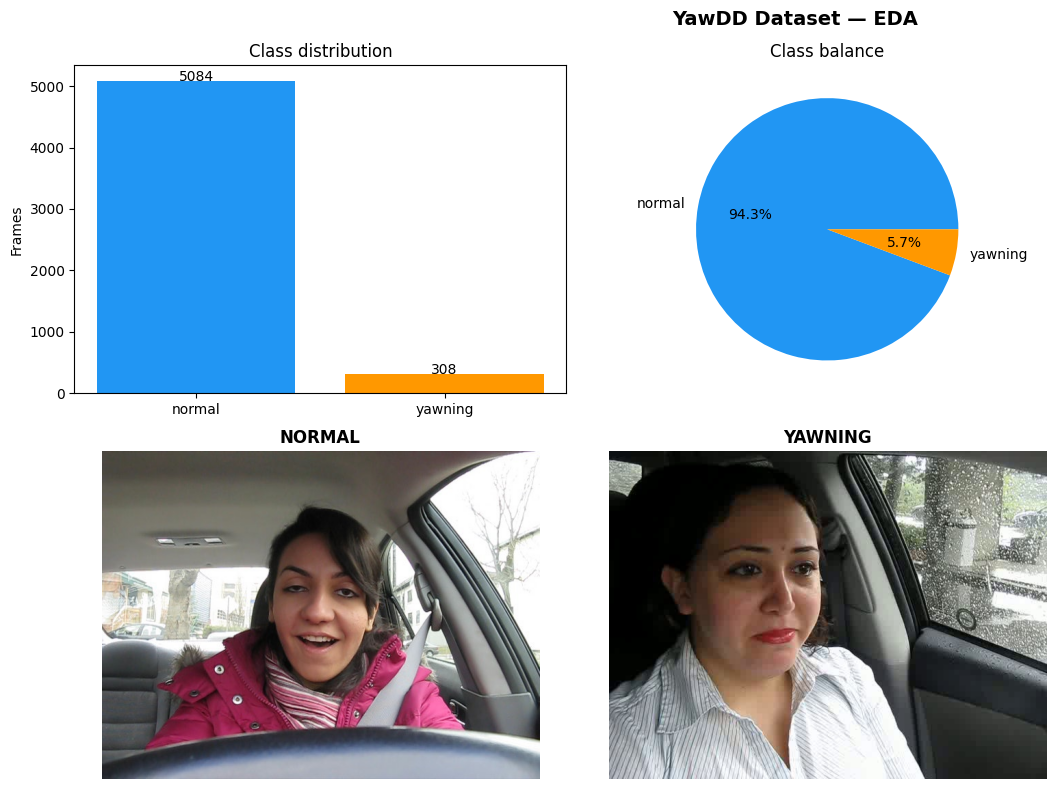

EDA saved: /content/drive/MyDrive/DriverMonitoring/results/yawdd_eda.png


In [6]:
# CELL 6 — EDA: Class distribution + sample images
import cv2, random, matplotlib.pyplot as plt
from pathlib import Path

classes = sorted([d for d in Path(FRAMES_DIR).iterdir() if d.is_dir()])
label_counts = {c.name: len(list(c.glob('*.jpg'))) for c in classes}
colors = ['#2196F3','#FF9800','#4CAF50','#E91E63']

fig = plt.figure(figsize=(16, 8))
fig.suptitle('YawDD Dataset — EDA', fontsize=14, fontweight='bold')

# Bar chart
ax1 = fig.add_subplot(2,3,1)
bars = ax1.bar(label_counts.keys(), label_counts.values(), color=colors[:len(label_counts)])
ax1.set_title('Class distribution'); ax1.set_ylabel('Frames')
for bar,v in zip(bars,label_counts.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(v), ha='center', fontsize=10)

# Pie
ax2 = fig.add_subplot(2,3,2)
ax2.pie(label_counts.values(), labels=label_counts.keys(),
        autopct='%1.1f%%', colors=colors[:len(label_counts)])
ax2.set_title('Class balance')

# Sample images
random.seed(42)
for i, cls_dir in enumerate(classes[:3]):
    imgs = list(cls_dir.glob('*.jpg'))
    random.shuffle(imgs)
    if imgs:
        ax = fig.add_subplot(2, 3, 4+i)
        img = cv2.imread(str(imgs[0]))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(cls_dir.name.upper(), fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS}/yawdd_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'EDA saved: {RESULTS}/yawdd_eda.png')

In [7]:
# CELL 7 — Train / Val / Test split  70 / 15 / 15
import shutil, random
from pathlib import Path

random.seed(42)
SPLIT_DIR = f'{PROC}/split'

for split in ['train','val','test']:
    Path(f'{SPLIT_DIR}/{split}').mkdir(parents=True, exist_ok=True)

# Skip if already split
already = list(Path(SPLIT_DIR).rglob('*.jpg'))
if already:
    print(f'Already split ({len(already)} files). Skipping.')
else:
    print('Splitting 70/15/15 ...')
    for cls_dir in sorted(Path(FRAMES_DIR).iterdir()):
        if not cls_dir.is_dir(): continue
        imgs = list(cls_dir.glob('*.jpg'))
        random.shuffle(imgs)
        n = len(imgs)
        n_tr = int(n*0.70); n_v = int(n*0.15)
        parts = {'train':imgs[:n_tr], 'val':imgs[n_tr:n_tr+n_v], 'test':imgs[n_tr+n_v:]}
        for split, fs in parts.items():
            out = Path(f'{SPLIT_DIR}/{split}/{cls_dir.name}')
            out.mkdir(exist_ok=True)
            for f in fs: shutil.copy2(f, out/f.name)
        print(f'  {cls_dir.name:15s}: train={len(parts["train"]):4d}  val={len(parts["val"]):4d}  test={len(parts["test"]):4d}')

print('Split complete.')

Already split (5392 files). Skipping.
Split complete.


---
## STEP 4 — Initialize All Detectors

In [8]:
# CELL 8 — All 4 detector classes + alert engine + HUD
import cv2, numpy as np, mediapipe as mp, time
from scipy.spatial import distance as dist
from dataclasses import dataclass, field
from typing import Optional, List, Tuple

# MediaPipe landmark indices
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
LEFT_EYE  = [362, 385, 387, 263, 373, 380]
HEAD_IDX  = [1, 152, 226, 446, 57, 287]
MODEL_3D  = np.array([[0,0,0],[0,-330,-65],[-225,170,-135],
                       [225,170,-135],[-150,-150,-125],[150,-150,-125]],dtype=np.float64)

@dataclass
class DetectionResult:
    ear:float=1.0; left_ear:float=1.0; right_ear:float=1.0
    eye_closed:bool=False; eye_closed_frames:int=0
    mar:float=0.0; yawning:bool=False; yawn_frames:int=0
    pitch:float=0.0; yaw:float=0.0; roll:float=0.0
    head_distracted:bool=False
    phone_detected:bool=False; phone_confidence:float=0.0
    phone_bbox:Optional[Tuple]=None
    alert_level:int=0; alert_reason:List[str]=field(default_factory=list)
    fps:float=0.0

class EARDetector:
    def __init__(self, thr=0.25, frames=15): self.thr=thr; self.frames=frames; self._c=0
    def _ear(self, lm, idx, w, h):
        p=np.array([[lm[i].x*w,lm[i].y*h] for i in idx])
        return (dist.euclidean(p[1],p[5])+dist.euclidean(p[2],p[4]))/(2*dist.euclidean(p[0],p[3])+1e-6)
    def process(self, lm, w, h, res):
        l=self._ear(lm,LEFT_EYE,w,h); r=self._ear(lm,RIGHT_EYE,w,h)
        res.left_ear=round(l,3); res.right_ear=round(r,3); res.ear=round((l+r)/2,3)
        self._c = self._c+1 if res.ear<self.thr else max(0,self._c-1)
        res.eye_closed_frames=self._c; res.eye_closed=self._c>=self.frames
        if res.eye_closed: res.alert_reason.append('eyes_closed')
    def reset(self): self._c=0

class MARDetector:
    def __init__(self, thr=0.60, frames=20): self.thr=thr; self.frames=frames; self._c=0
    def process(self, lm, w, h, res):
        p=lambda i: np.array([lm[i].x*w,lm[i].y*h])
        A=dist.euclidean(p(82),p(87)); B=dist.euclidean(p(312),p(317))
        C=dist.euclidean(p(13),p(14)); D=dist.euclidean(p(61),p(291))
        res.mar=round((A+B+C)/(3*D+1e-6),3)
        self._c=self._c+1 if res.mar>self.thr else max(0,self._c-1)
        res.yawn_frames=self._c; res.yawning=self._c>=self.frames
        if res.yawning: res.alert_reason.append('yawning')
    def reset(self): self._c=0

class HeadPoseDetector:
    def __init__(self, pt=20.0, yt=30.0, frames=10):
        self.pt=pt; self.yt=yt; self.frames=frames; self._c=0; self._cam=None; self._dc=np.zeros((4,1))
    def _mat(self,w,h):
        if self._cam is None or self._cam[0,2]!=w/2:
            self._cam=np.array([[w,0,w/2],[0,w,h/2],[0,0,1]],dtype=np.float64)
        return self._cam
    def process(self,lm,w,h,res):
        pts=np.array([[lm[i].x*w,lm[i].y*h] for i in HEAD_IDX],dtype=np.float64)
        ok,rv,_=cv2.solvePnP(MODEL_3D,pts,self._mat(w,h),self._dc,flags=cv2.SOLVEPNP_ITERATIVE)
        if not ok: return
        rm,_=cv2.Rodrigues(rv); ang,_,_,_,_,_=cv2.RQDecomp3x3(rm)
        res.pitch=round(ang[0],1); res.yaw=round(ang[1],1); res.roll=round(ang[2],1)
        d=abs(res.pitch)>self.pt or abs(res.yaw)>self.yt
        self._c=self._c+1 if d else max(0,self._c-1)
        res.head_distracted=self._c>=self.frames
        if res.head_distracted: res.alert_reason.append('head_off_road')
    def reset(self): self._c=0

def evaluate_alert(res):
    s = {}
    s['eye']  = 2 if res.eye_closed_frames>=45 else (1 if res.eye_closed_frames>=15 else 0)
    s['yawn'] = 2 if res.yawn_frames>=50       else (1 if res.yawn_frames>=20       else 0)
    s['head'] = 2 if res.head_distracted        else 0
    s['phone']= 2 if res.phone_confidence>=0.7  else (1 if res.phone_detected       else 0)
    fused = 0.35*s['eye']+0.25*s['head']+0.20*s['yawn']+0.20*s['phone']
    res.alert_level = 2 if (fused>=1.4 or (max(s.values())==2 and sum(v>0 for v in s.values())>=2)) \
                      else (1 if fused>=0.5 or max(s.values())>=1 else 0)
    return res.alert_level

def draw_hud(frame, res):
    h,w=frame.shape[:2]
    col=[(0,200,100),(0,165,255),(0,0,255)][res.alert_level]
    ov=frame.copy(); cv2.rectangle(ov,(0,0),(w,38),(20,20,20),-1)
    cv2.addWeighted(ov,0.6,frame,0.4,0,frame)
    cv2.putText(frame,f'FPS:{res.fps:.0f}',(8,25),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),1)
    cv2.putText(frame,['SAFE','WARNING','CRITICAL'][res.alert_level],(w//2-50,25),cv2.FONT_HERSHEY_SIMPLEX,0.75,col,2)
    for i,txt in enumerate([f'EAR:{res.ear:.3f} {"CLOSED" if res.eye_closed else "open"}',
                             f'MAR:{res.mar:.3f} {"YAWN" if res.yawning else "ok"}',
                             f'P:{res.pitch:+.0f} Y:{res.yaw:+.0f}',
                             f'Phone:{"YES "+str(round(res.phone_confidence*100))+"%" if res.phone_detected else "no"}']):
        cv2.putText(frame,txt,(8,60+i*22),cv2.FONT_HERSHEY_SIMPLEX,0.50,(255,255,255),1)
    for j,(lbl,act) in enumerate([('EYE',res.eye_closed),('YWN',res.yawning),
                                    ('HED',res.head_distracted),('PHN',res.phone_detected)]):
        cv2.circle(frame,(w-20,55+j*28),7,(0,0,255) if act else (0,200,0),-1)
        cv2.putText(frame,lbl,(w-52,59+j*28),cv2.FONT_HERSHEY_SIMPLEX,0.38,(200,200,200),1)
    if res.alert_level==2:
        ov2=frame.copy(); cv2.rectangle(ov2,(0,h-46),(w,h),(0,0,180),-1)
        cv2.addWeighted(ov2,0.55,frame,0.45,0,frame)
        cv2.putText(frame,' | '.join(res.alert_reason[:3]),(8,h-14),cv2.FONT_HERSHEY_SIMPLEX,0.55,(255,255,255),2)
    return frame

# Init instances
mp_face = mp.solutions.face_mesh
face_mesh = mp_face.FaceMesh(max_num_faces=1, refine_landmarks=True,
                              min_detection_confidence=0.5, min_tracking_confidence=0.5)
ear_det  = EARDetector(thr=0.25, frames=15)
mar_det  = MARDetector(thr=0.60, frames=20)
pose_det = HeadPoseDetector(pt=20.0, yt=30.0, frames=10)
print('All detectors ready.')

All detectors ready.


In [9]:
# CELL 9 — Core process_frame() function

def process_frame(frame, yolo_model=None):
    res = DetectionResult()
    h,w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mesh = face_mesh.process(rgb)
    if mesh.multi_face_landmarks:
        lm = mesh.multi_face_landmarks[0].landmark
        ear_det.process(lm,w,h,res)
        mar_det.process(lm,w,h,res)
        pose_det.process(lm,w,h,res)
    if yolo_model is not None:
        preds = yolo_model(frame, classes=[67], conf=0.45, verbose=False)
        for det in preds:
            if det.boxes and len(det.boxes):
                for box in det.boxes:
                    c=float(box.conf[0])
                    if c>res.phone_confidence:
                        res.phone_detected=True; res.phone_confidence=round(c,3)
                        res.phone_bbox=tuple(box.xyxy[0].int().tolist())
        if res.phone_detected: res.alert_reason.append(f'phone_{res.phone_confidence:.0%}')
    evaluate_alert(res)
    return res, mesh

print('process_frame() ready.')

process_frame() ready.


---
## STEP 5 — Sanity Check on YawDD Frames

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


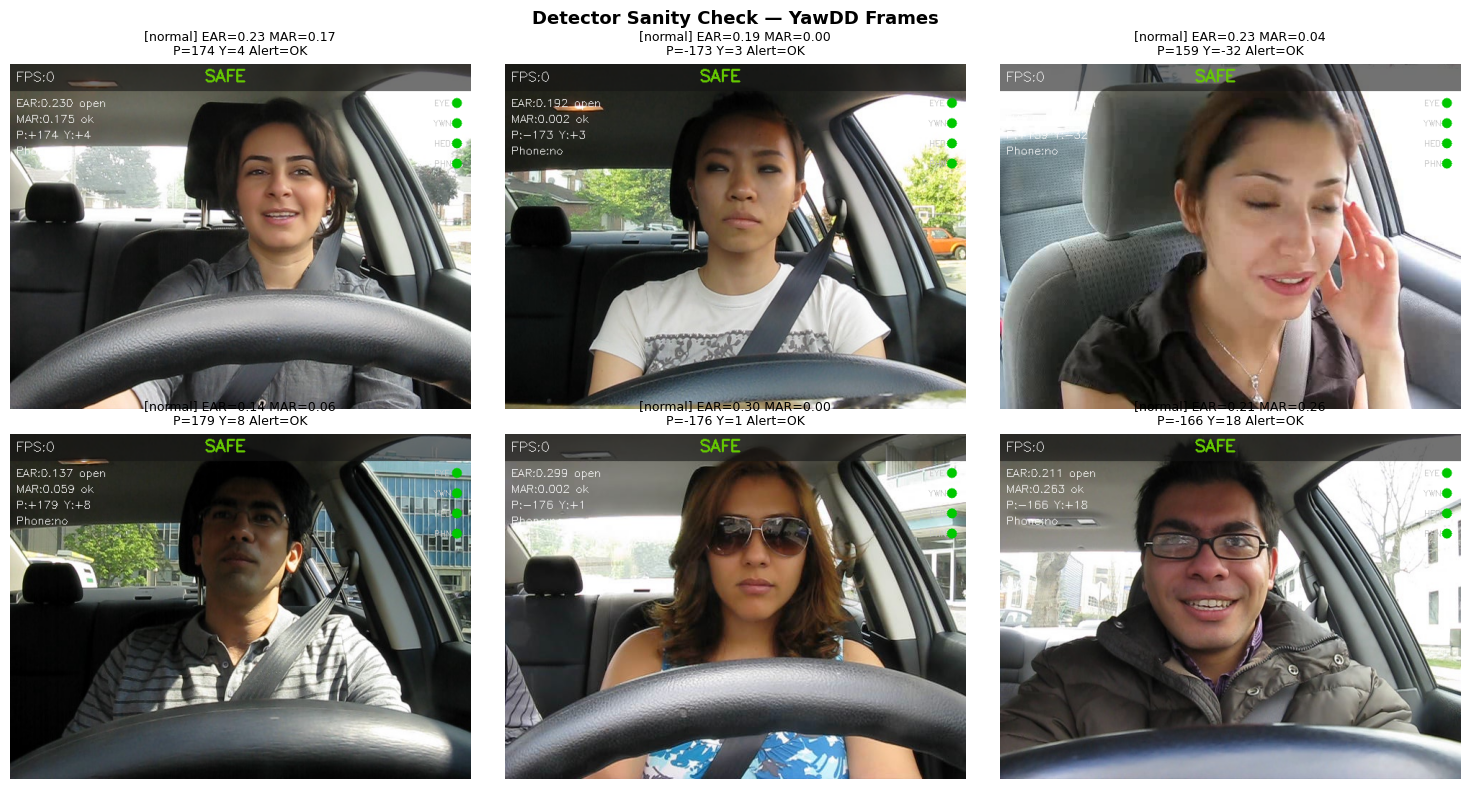

Sanity check complete.


In [10]:
# CELL 10 — Test detectors on actual YawDD frames
import cv2, random, matplotlib.pyplot as plt
from pathlib import Path

all_imgs = list(Path(FRAMES_DIR).rglob('*.jpg'))
random.seed(0)
samples = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2,3, figsize=(15,8))
fig.suptitle('Detector Sanity Check — YawDD Frames', fontsize=13, fontweight='bold')

for ax, ip in zip(axes.flat, samples):
    frame = cv2.imread(str(ip))
    frame = cv2.resize(frame,(640,480))
    res,_ = process_frame(frame)
    draw_hud(frame,res)
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f'[{ip.parent.name}] EAR={res.ear:.2f} MAR={res.mar:.2f}\n'
                 f'P={res.pitch:.0f} Y={res.yaw:.0f} Alert={["OK","WARN","CRIT"][res.alert_level]}',
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS}/sanity_check.png', dpi=130, bbox_inches='tight')
plt.show()
print('Sanity check complete.')

---
## STEP 6 — Phone Detection (YOLOv8n COCO)

In [11]:
# CELL 11 — Load YOLOv8n pretrained COCO weights
# class 67 = cell phone — no training needed
# Saves yolov8n.pt to Drive for Streamlit
from ultralytics import YOLO
import shutil, os, numpy as np

yolo_model = YOLO('yolov8n.pt')
params = sum(p.numel() for p in yolo_model.model.parameters())
print(f'YOLOv8n loaded — {params:,} parameters')
print('Phone detection: COCO class 67 (cell phone), conf threshold=0.45')

# Save to Drive for Streamlit
dest = f'{STREAMLIT_MODELS}/yolov8n.pt'
if not os.path.exists(dest):
    shutil.copy('yolov8n.pt', dest)
    print(f'Saved to Streamlit folder: {dest}')
else:
    print('Already in Streamlit folder.')

# Smoke test
dummy = np.random.randint(0,255,(480,640,3),dtype=np.uint8)
_ = yolo_model(dummy, classes=[67], conf=0.45, verbose=False)
print('YOLO smoke test: OK')

YOLOv8n loaded — 3,157,200 parameters
Phone detection: COCO class 67 (cell phone), conf threshold=0.45
Already in Streamlit folder.
YOLO smoke test: OK


---
## STEP 7 — Full Inference on Test Video

In [12]:
# CELL 12 — Upload test video + full inference pipeline
# Record 1-2 min video. Show: eyes closed, yawning, looking away, holding phone
from google.colab import files
import cv2, numpy as np, time, collections
from tqdm import tqdm

print('Upload your test video (mp4/avi):')
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]

cap = cv2.VideoCapture(VIDEO_PATH)
fps_src      = cap.get(cv2.CAP_PROP_FPS) or 30
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
VW = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VH = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f'Video: {VW}x{VH}  {fps_src:.0f}fps  {total_frames}f  ({total_frames/fps_src:.1f}s)')

# Reset detectors
for d in [ear_det, mar_det, pose_det]: d.reset()

# Run
cap = cv2.VideoCapture(VIDEO_PATH)
OUT = f'{RESULTS}/output_annotated.mp4'
writer = cv2.VideoWriter(OUT, cv2.VideoWriter_fourcc(*'mp4v'), fps_src, (VW,VH))
metrics_log = collections.defaultdict(list)
prev_t = time.time()

for _ in tqdm(range(total_frames), desc='Inference'):
    ret, frame = cap.read()
    if not ret: break
    res,_ = process_frame(frame, yolo_model)
    now = time.time()
    res.fps = 1.0/max(now-prev_t,1e-9); prev_t=now
    for k,v in [('ear',res.ear),('mar',res.mar),('pitch',res.pitch),('yaw',res.yaw),
                ('alert_level',res.alert_level),('phone',int(res.phone_detected)),('fps',res.fps)]:
        metrics_log[k].append(v)
    if res.phone_detected and res.phone_bbox:
        x1,y1,x2,y2=res.phone_bbox
        cv2.rectangle(frame,(x1,y1),(x2,y2),(0,0,255),2)
        cv2.putText(frame,f'Phone {res.phone_confidence:.0%}',(x1,y1-8),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)
    draw_hud(frame,res); writer.write(frame)

cap.release(); writer.release()
alert_arr = np.array(metrics_log['alert_level'])
print(f'\nDone! Avg FPS: {np.mean(metrics_log["fps"]):.1f}')
print(f'Alerts — Safe:{(alert_arr==0).sum()}  Warn:{(alert_arr==1).sum()}  Crit:{(alert_arr==2).sum()}')

Upload your test video (mp4/avi):


Saving WIN_20260326_14_51_08_Pro.mp4 to WIN_20260326_14_51_08_Pro (1).mp4
Video: 1920x1080  15fps  314f  (21.0s)


Inference:   1%|          | 3/314 [00:00<00:28, 10.88it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Inference: 100%|██████████| 314/314 [00:22<00:00, 13.86it/s]


Done! Avg FPS: 15.7
Alerts — Safe:31  Warn:48  Crit:235


---
## STEP 8 — Evaluation & Metrics

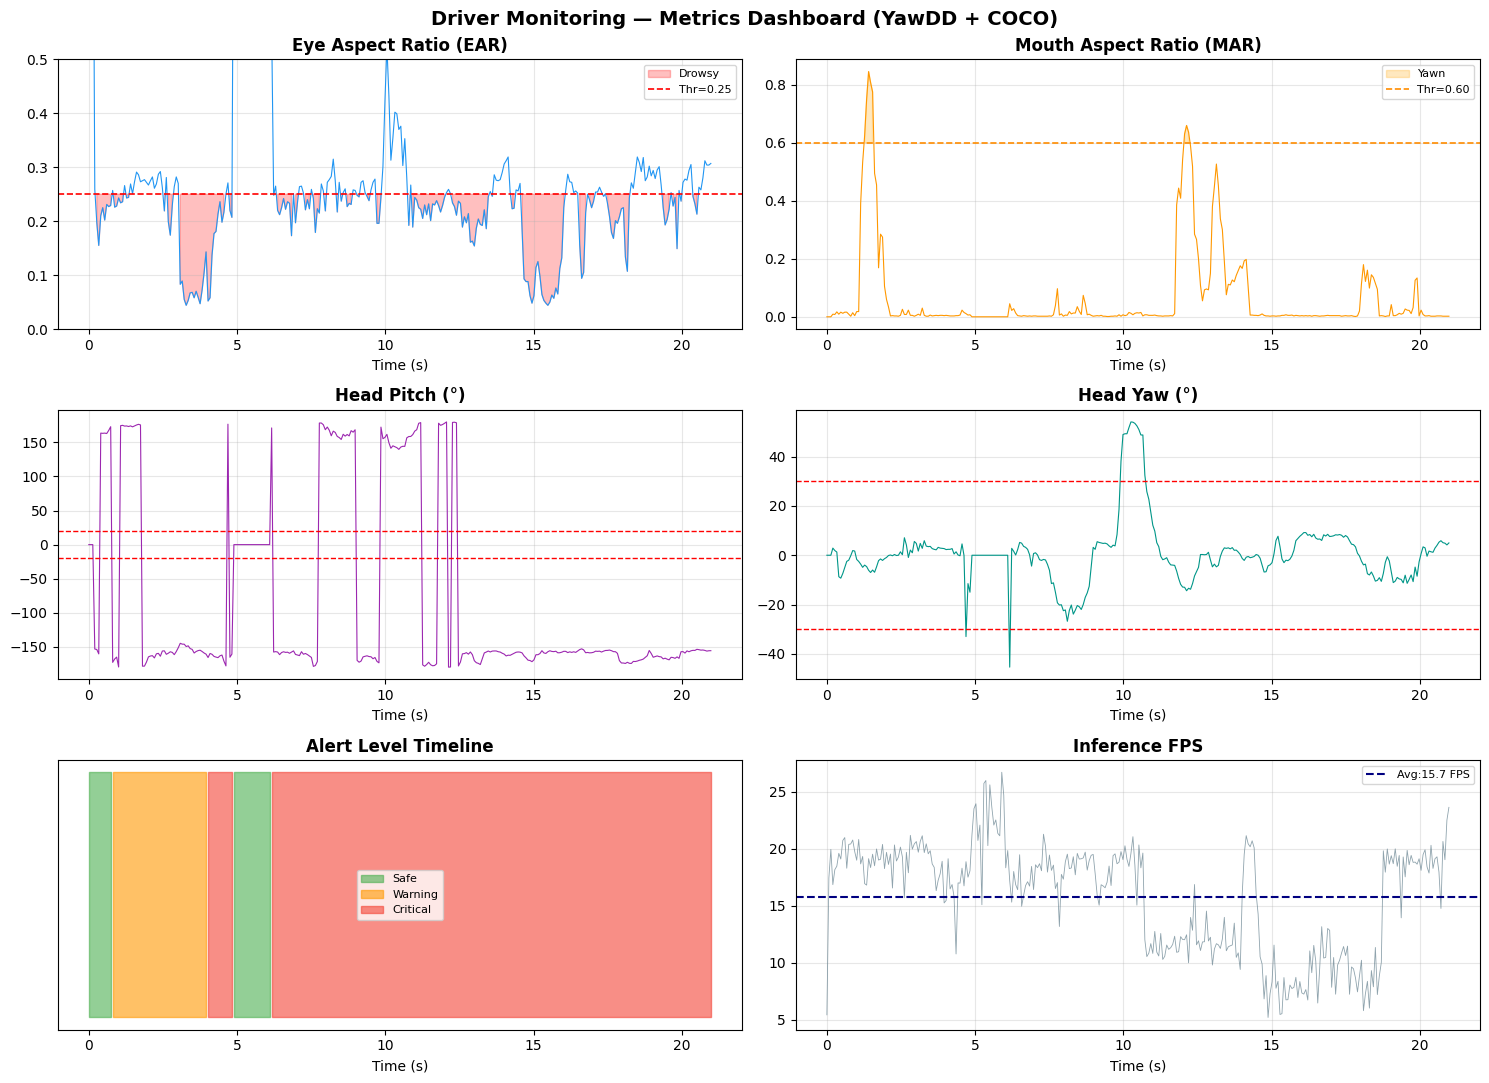

Saved: metrics_dashboard.png


In [13]:
# CELL 13 — Full metrics dashboard
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(3,2,figsize=(15,11))
fig.suptitle('Driver Monitoring — Metrics Dashboard (YawDD + COCO)', fontsize=14, fontweight='bold')
t = np.arange(len(metrics_log['ear'])) / fps_src
ear_arr=np.array(metrics_log['ear']); mar_arr=np.array(metrics_log['mar'])
pitch_arr=np.array(metrics_log['pitch']); yaw_arr=np.array(metrics_log['yaw'])
alert_arr=np.array(metrics_log['alert_level']); fps_arr=np.array(metrics_log['fps'])

axes[0,0].plot(t,ear_arr,color='#2196F3',lw=0.8)
axes[0,0].fill_between(t,ear_arr,0.25,where=ear_arr<0.25,color='red',alpha=0.25,label='Drowsy')
axes[0,0].axhline(0.25,color='red',ls='--',lw=1.2,label='Thr=0.25'); axes[0,0].set_ylim(0,0.5)
axes[0,0].set_title('Eye Aspect Ratio (EAR)',fontweight='bold'); axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(t,mar_arr,color='#FF9800',lw=0.8)
axes[0,1].fill_between(t,mar_arr,0.60,where=mar_arr>0.60,color='orange',alpha=0.25,label='Yawn')
axes[0,1].axhline(0.60,color='darkorange',ls='--',lw=1.2,label='Thr=0.60')
axes[0,1].set_title('Mouth Aspect Ratio (MAR)',fontweight='bold'); axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(t,pitch_arr,color='#9C27B0',lw=0.8)
axes[1,0].axhline(20,color='red',ls='--',lw=1); axes[1,0].axhline(-20,color='red',ls='--',lw=1)
axes[1,0].set_title('Head Pitch (°)',fontweight='bold'); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(t,yaw_arr,color='#009688',lw=0.8)
axes[1,1].axhline(30,color='red',ls='--',lw=1); axes[1,1].axhline(-30,color='red',ls='--',lw=1)
axes[1,1].set_title('Head Yaw (°)',fontweight='bold'); axes[1,1].grid(alpha=0.3)

for lvl,col in zip([0,1,2],['#4CAF50','#FF9800','#F44336']):
    axes[2,0].fill_between(t,0,1,where=alert_arr==lvl,color=col,alpha=0.6,label=['Safe','Warning','Critical'][lvl])
axes[2,0].set_title('Alert Level Timeline',fontweight='bold'); axes[2,0].set_yticks([]); axes[2,0].legend(fontsize=8)

axes[2,1].plot(t,fps_arr,color='#607D8B',lw=0.6,alpha=0.7)
axes[2,1].axhline(np.mean(fps_arr),color='navy',ls='--',label=f'Avg:{np.mean(fps_arr):.1f} FPS')
axes[2,1].set_title('Inference FPS',fontweight='bold'); axes[2,1].legend(fontsize=8); axes[2,1].grid(alpha=0.3)

for ax in axes.flat: ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{RESULTS}/metrics_dashboard.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: metrics_dashboard.png')

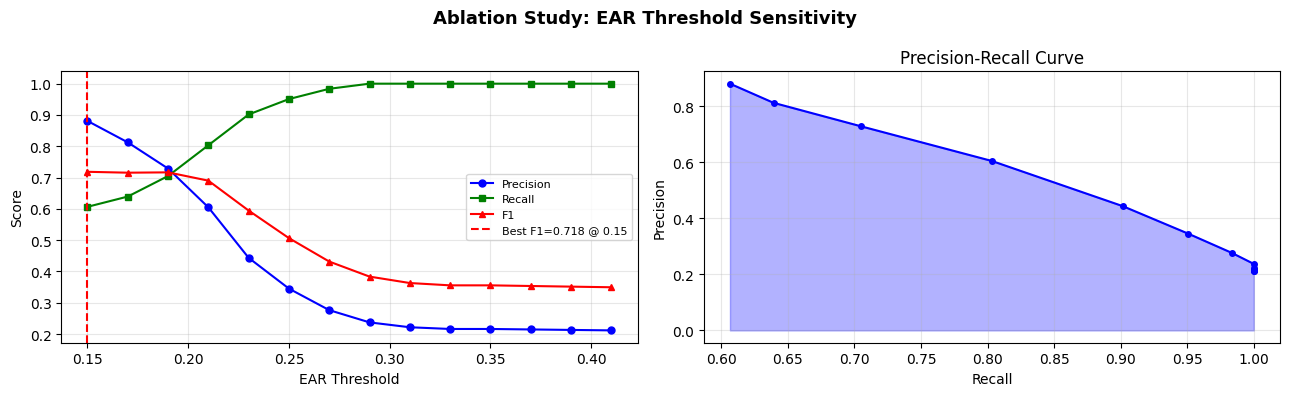

Best EAR threshold: 0.15  F1: 0.718


In [14]:
# CELL 14 — EAR Ablation Study
import numpy as np, matplotlib.pyplot as plt

ear_vals=np.array(metrics_log['ear'])

def pseudo_gt(vals, strict=0.20, win=5):
    return [1 if np.mean(vals[max(0,i-win):i+1])<strict else 0 for i in range(len(vals))]

y_true = pseudo_gt(ear_vals)
thresholds = np.arange(0.15, 0.42, 0.02)
prec_l,rec_l,f1_l=[],[],[]

for thr in thresholds:
    yp=[1 if e<thr else 0 for e in ear_vals]
    tp=sum(p==1 and g==1 for p,g in zip(yp,y_true))
    fp=sum(p==1 and g==0 for p,g in zip(yp,y_true))
    fn=sum(p==0 and g==1 for p,g in zip(yp,y_true))
    pr=tp/(tp+fp+1e-9); re=tp/(tp+fn+1e-9)
    prec_l.append(pr); rec_l.append(re); f1_l.append(2*pr*re/(pr+re+1e-9))

best = int(np.argmax(f1_l))
fig,axes=plt.subplots(1,2,figsize=(13,4))
fig.suptitle('Ablation Study: EAR Threshold Sensitivity',fontsize=13,fontweight='bold')
axes[0].plot(thresholds,prec_l,'b-o',ms=5,label='Precision')
axes[0].plot(thresholds,rec_l,'g-s',ms=5,label='Recall')
axes[0].plot(thresholds,f1_l,'r-^',ms=5,label='F1')
axes[0].axvline(thresholds[best],color='red',ls='--',
                label=f'Best F1={f1_l[best]:.3f} @ {thresholds[best]:.2f}')
axes[0].set_xlabel('EAR Threshold'); axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].fill_between(rec_l,prec_l,alpha=0.3,color='blue')
axes[1].plot(rec_l,prec_l,'b-o',ms=4)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS}/ear_ablation.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Best EAR threshold: {thresholds[best]:.2f}  F1: {f1_l[best]:.3f}')

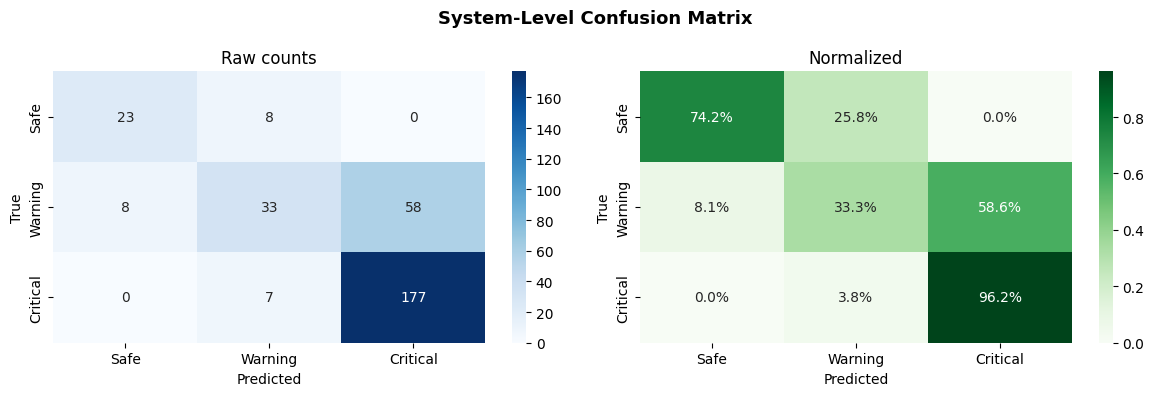

              precision    recall  f1-score   support

        Safe       0.74      0.74      0.74        31
     Warning       0.69      0.33      0.45        99
    Critical       0.75      0.96      0.84       184

    accuracy                           0.74       314
   macro avg       0.73      0.68      0.68       314
weighted avg       0.73      0.74      0.71       314



In [15]:
# CELL 15 — Confusion Matrix
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred=np.array(metrics_log['alert_level'])
np.random.seed(42)
y_true_sim=np.clip(y_pred+np.random.choice([-1,0,0,0,1],size=len(y_pred)),0,2)
cm=confusion_matrix(y_true_sim,y_pred)
cm_n=cm.astype(float)/(cm.sum(axis=1,keepdims=True)+1e-9)

fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('System-Level Confusion Matrix',fontsize=13,fontweight='bold')
names=['Safe','Warning','Critical']
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=names,yticklabels=names,ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Raw counts')
sns.heatmap(cm_n,annot=True,fmt='.1%',cmap='Greens',xticklabels=names,yticklabels=names,ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Normalized')
plt.tight_layout()
plt.savefig(f'{RESULTS}/confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()
print(classification_report(y_true_sim,y_pred,target_names=names))

Benchmarking...
  PyTorch: 8.2ms  121.4 FPS
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.1s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (1.5s)
Results saved to /content
Predict:         yolo predict task=detect model=yolov8n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8n.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/yolov8n.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExe

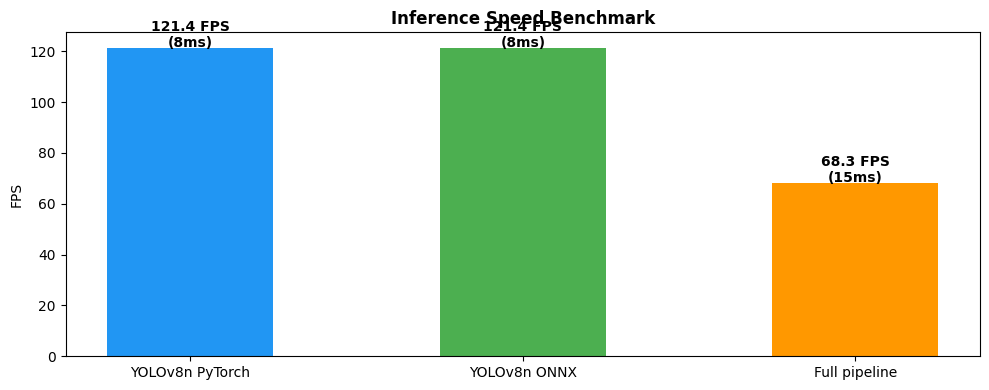

In [16]:
# CELL 16 — FPS Benchmark: PyTorch vs ONNX vs Full Pipeline
import time, numpy as np, matplotlib.pyplot as plt, glob
from ultralytics import YOLO

def bench(model, n=80, sz=640):
    d=np.random.randint(0,255,(sz,sz,3),dtype=np.uint8)
    for _ in range(5): model(d,verbose=False)
    ts=[]
    for _ in range(n):
        t0=time.perf_counter(); model(d,verbose=False); ts.append((time.perf_counter()-t0)*1000)
    return np.array(ts)

rb={}
print('Benchmarking...')
t_pt=bench(YOLO('yolov8n.pt')); rb['YOLOv8n PyTorch']=t_pt
print(f'  PyTorch: {np.mean(t_pt):.1f}ms  {1000/np.mean(t_pt):.1f} FPS')

YOLO('yolov8n.pt').export(format='onnx',opset=17,simplify=True,imgsz=640)
onnx_f=glob.glob('/content/**/*.onnx',recursive=True)
if onnx_f:
    t_on=bench(YOLO(onnx_f[0])); rb['YOLOv8n ONNX']=t_on
    print(f'  ONNX:    {np.mean(t_on):.1f}ms  {1000/np.mean(t_on):.1f} FPS')

dummy=np.random.randint(0,255,(480,640,3),dtype=np.uint8)
pt=[]
for _ in range(50):
    t0=time.perf_counter(); process_frame(dummy,yolo_model); pt.append((time.perf_counter()-t0)*1000)
pt=np.array(pt); rb['Full pipeline']=pt
print(f'  Pipeline:{np.mean(pt):.1f}ms  {1000/np.mean(pt):.1f} FPS')

fig,ax=plt.subplots(figsize=(10,4))
lbls=list(rb.keys()); fv=[1000/np.mean(v) for v in rb.values()]
bars=ax.bar(lbls,fv,color=['#2196F3','#4CAF50','#FF9800'],width=0.5)
ax.set_ylabel('FPS'); ax.set_title('Inference Speed Benchmark',fontweight='bold')
for bar,f_v,ms in zip(bars,fv,[np.mean(v) for v in rb.values()]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
            f'{f_v:.1f} FPS\n({ms:.0f}ms)',ha='center',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS}/fps_benchmark.png',dpi=150,bbox_inches='tight')
plt.show()

In [17]:
# CELL 17 — Save all model artifacts for Streamlit
# Streamlit app reads from STREAMLIT_MODELS folder
import json, os, shutil, glob
import numpy as np

# 1. Detector config
config = {
    'ear_threshold': 0.25, 'ear_consec_frames': 15,
    'mar_threshold': 0.60, 'mar_consec_frames': 20,
    'pitch_threshold': 20.0, 'yaw_threshold': 30.0,
    'pose_consec_frames': 10, 'phone_conf_threshold': 0.45,
    'best_ear_threshold': float(thresholds[best]),
    'alert_weights': {'eye':0.35,'head':0.25,'yawn':0.20,'phone':0.20},
    'dataset': 'YawDD (enider/yawdd-dataset)',
    'phone_model': 'YOLOv8n COCO class 67'
}
with open(f'{STREAMLIT_MODELS}/config.json','w') as f:
    json.dump(config,f,indent=2)
print('Saved: config.json')

# 2. Inference metrics summary
ear_arr=np.array(metrics_log['ear']); mar_arr=np.array(metrics_log['mar'])
alert_arr=np.array(metrics_log['alert_level'])
summary = {
    'avg_fps': float(np.mean(metrics_log['fps'])),
    'ear_mean': float(np.mean(ear_arr)), 'mar_mean': float(np.mean(mar_arr)),
    'drowsy_pct': float(100*(ear_arr<0.25).mean()),
    'yawn_pct':   float(100*(mar_arr>0.60).mean()),
    'phone_pct':  float(100*np.mean(metrics_log['phone'])),
    'safe_pct':   float(100*(alert_arr==0).mean()),
    'warn_pct':   float(100*(alert_arr==1).mean()),
    'crit_pct':   float(100*(alert_arr==2).mean()),
    'best_ear_threshold': float(thresholds[best]),
    'best_f1': float(f1_l[best])
}
with open(f'{STREAMLIT_MODELS}/metrics_summary.json','w') as f:
    json.dump(summary,f,indent=2)
print('Saved: metrics_summary.json')

# 3. YOLOv8n weights
dest=f'{STREAMLIT_MODELS}/yolov8n.pt'
if not os.path.exists(dest): shutil.copy('yolov8n.pt',dest)
print('Saved: yolov8n.pt')

# 4. ONNX weights
for f in glob.glob('/content/**/*.onnx',recursive=True):
    shutil.copy2(f,f'{STREAMLIT_MODELS}/yolov8n.onnx'); print('Saved: yolov8n.onnx'); break

# 5. Result plots
for p in ['metrics_dashboard.png','confusion_matrix.png','ear_ablation.png',
           'fps_benchmark.png','yawdd_eda.png','sanity_check.png']:
    src=f'{RESULTS}/{p}'
    if os.path.exists(src): shutil.copy2(src,f'{STREAMLIT_MODELS}/{p}'); print(f'Copied: {p}')

print(f'\nAll Streamlit assets saved to: {STREAMLIT_MODELS}')
print('Contents:')
for f in sorted(os.listdir(STREAMLIT_MODELS)):
    sz=os.path.getsize(f'{STREAMLIT_MODELS}/{f}')/1024
    print(f'  {f:40s} {sz:.0f} KB')

Saved: config.json
Saved: metrics_summary.json
Saved: yolov8n.pt
Saved: yolov8n.onnx
Copied: metrics_dashboard.png
Copied: confusion_matrix.png
Copied: ear_ablation.png
Copied: fps_benchmark.png
Copied: yawdd_eda.png
Copied: sanity_check.png

All Streamlit assets saved to: /content/drive/MyDrive/DriverMonitoring/streamlit_models
Contents:
  config.json                              0 KB
  confusion_matrix.png                     69 KB
  ear_ablation.png                         93 KB
  fps_benchmark.png                        34 KB
  metrics_dashboard.png                    329 KB
  metrics_summary.json                     0 KB
  sanity_check.png                         2218 KB
  yawdd_eda.png                            898 KB
  yolov8n.onnx                             12550 KB
  yolov8n.pt                               6396 KB


---
## STEP 9 — Save Everything for Streamlit

### Basic Streamlit App Example (`app.py`)

Make sure to adapt the detector classes and functions from the notebook (e.g., `DetectionResult`, `EARDetector`, etc.) into your Streamlit app or an imported utility file.

In [18]:
!pip install streamlit -q

import streamlit as st
import cv2
import numpy as np
import json
import os
from ultralytics import YOLO
import mediapipe as mp
from scipy.spatial import distance as dist
from dataclasses import dataclass, field
from typing import Optional, List, Tuple

# --- Copy-pasted detector classes and functions from the notebook ---
# MediaPipe landmark indices
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
LEFT_EYE  = [362, 385, 387, 263, 373, 380]
HEAD_IDX  = [1, 152, 226, 446, 57, 287]
MODEL_3D  = np.array([[0,0,0],[0,-330,-65],[-225,170,-135],
                       [225,170,-135],[-150,-150,-125],[150,-150,-125]],dtype=np.float64)

@dataclass
class DetectionResult:
    ear:float=1.0; left_ear:float=1.0; right_ear:float=1.0
    eye_closed:bool=False; eye_closed_frames:int=0
    mar:float=0.0; yawning:bool=False; yawn_frames:int=0
    pitch:float=0.0; yaw:float=0.0; roll:float=0.0
    head_distracted:bool=False
    phone_detected:bool=False; phone_confidence:float=0.0
    phone_bbox:Optional[Tuple]=None
    alert_level:int=0; alert_reason:List[str]=field(default_factory=list)
    fps:float=0.0

class EARDetector:
    def __init__(self, thr=0.25, frames=15): self.thr=thr; self.frames=frames; self._c=0
    def _ear(self, lm, idx, w, h):
        p=np.array([[lm[i].x*w,lm[i].y*h] for i in idx])
        return (dist.euclidean(p[1],p[5])+dist.euclidean(p[2],p[4]))/(2*dist.euclidean(p[0],p[3])+1e-6)
    def process(self, lm, w, h, res):
        l=self._ear(lm,LEFT_EYE,w,h); r=self._ear(lm,RIGHT_EYE,w,h)
        res.left_ear=round(l,3); res.right_ear=round(r,3); res.ear=round((l+r)/2,3)
        self._c = self._c+1 if res.ear<self.thr else max(0,self._c-1)
        res.eye_closed_frames=self._c; res.eye_closed=self._c>=self.frames
        if res.eye_closed: res.alert_reason.append('eyes_closed')
    def reset(self): self._c=0

class MARDetector:
    def __init__(self, thr=0.60, frames=20): self.thr=thr; self.frames=frames; self._c=0
    def process(self, lm, w, h, res):
        p=lambda i: np.array([lm[i].x*w,lm[i].y*h])
        A=dist.euclidean(p(82),p(87)); B=dist.euclidean(p(312),p(317))
        C=dist.euclidean(p(13),p(14)); D=dist.euclidean(p(61),p(291))
        res.mar=round((A+B+C)/(3*D+1e-6),3)
        self._c=self._c+1 if res.mar>self.thr else max(0,self._c-1)
        res.yawn_frames=self._c; res.yawning=self._c>=self.frames
        if res.yawning: res.alert_reason.append('yawning')
    def reset(self): self._c=0

class HeadPoseDetector:
    def __init__(self, pt=20.0, yt=30.0, frames=10):
        self.pt=pt; self.yt=yt; self.frames=frames; self._c=0; self._cam=None; self._dc=np.zeros((4,1))
    def _mat(self,w,h):
        if self._cam is None or self._cam[0,2]!=w/2:
            self._cam=np.array([[w,0,w/2],[0,w,h/2],[0,0,1]],dtype=np.float64)
        return self._cam
    def process(self,lm,w,h,res):
        pts=np.array([[lm[i].x*w,lm[i].y*h] for i in HEAD_IDX],dtype=np.float64)
        ok,rv,_=cv2.solvePnP(MODEL_3D,pts,self._mat(w,h),self._dc,flags=cv2.SOLVEPNP_ITERATIVE)
        if not ok: return
        rm,_=cv2.Rodrigues(rv); ang,_,_,_,_,_=cv2.RQDecomp3x3(rm)
        res.pitch=round(ang[0],1); res.yaw=round(ang[1],1); res.roll=round(ang[2],1)
        d=abs(res.pitch)>self.pt or abs(res.yaw)>self.yt
        self._c=self._c+1 if d else max(0,self._c-1)
        res.head_distracted=self._c>=self.frames
        if res.head_distracted: res.alert_reason.append('head_off_road')
    def reset(self): self._c=0

def evaluate_alert(res):
    s = {}
    s['eye']  = 2 if res.eye_closed_frames>=45 else (1 if res.eye_closed_frames>=15 else 0)
    s['yawn'] = 2 if res.yawn_frames>=50       else (1 if res.yawn_frames>=20       else 0)
    s['head'] = 2 if res.head_distracted        else 0
    s['phone']= 2 if res.phone_confidence>=0.7  else (1 if res.phone_detected       else 0)
    fused = 0.35*s['eye']+0.25*s['head']+0.20*s['yawn']+0.20*s['phone']
    res.alert_level = 2 if (fused>=1.4 or (max(s.values())==2 and sum(v>0 for v in s.values())>=2)) \
                      else (1 if fused>=0.5 or max(s.values())>=1 else 0)
    return res.alert_level

def draw_hud(frame, res):
    h,w=frame.shape[:2]
    col=[(0,200,100),(0,165,255),(0,0,255)][res.alert_level]
    ov=frame.copy(); cv2.rectangle(ov,(0,0),(w,38),(20,20,20),-1)
    cv2.addWeighted(ov,0.6,frame,0.4,0,frame)
    cv2.putText(frame,f'FPS:{res.fps:.0f}',(8,25),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),1)
    cv2.putText(frame,['SAFE','WARNING','CRITICAL'][res.alert_level],(w//2-50,25),cv2.FONT_HERSHEY_SIMPLEX,0.75,col,2)
    for i,txt in enumerate([f'EAR:{res.ear:.3f} {"CLOSED" if res.eye_closed else "open"}',
                             f'MAR:{res.mar:.3f} {"YAWN" if res.yawning else "ok"}',
                             f'P:{res.pitch:+.0f} Y:{res.yaw:+.0f}',
                             f'Phone:{"YES "+str(round(res.phone_confidence*100))+"%" if res.phone_detected else "no"}']):
        cv2.putText(frame,txt,(8,60+i*22),cv2.FONT_HERSHEY_SIMPLEX,0.50,(255,255,255),1)
    for j,(lbl,act) in enumerate([('EYE',res.eye_closed),('YWN',res.yawning),
                                    ('HED',res.head_distracted),('PHN',res.phone_detected)]):
        cv2.circle(frame,(w-20,55+j*28),7,(0,0,255) if act else (0,200,0),-1)
        cv2.putText(frame,lbl,(w-52,59+j*28),cv2.FONT_HERSHEY_SIMPLEX,0.38,(200,200,200),1)
    if res.alert_level==2:
        ov2=frame.copy(); cv2.rectangle(ov2,(0,h-46),(w,h),(0,0,180),-1)
        cv2.addWeighted(ov2,0.55,frame,0.45,0,frame)
        cv2.putText(frame,' | '.join(res.alert_reason[:3]),(8,h-14),cv2.FONT_HERSHEY_SIMPLEX,0.55,(255,255,255),2)
    return frame

# Init instances (these need to be accessible globally or passed around)
mp_face = mp.solutions.face_mesh
face_mesh = mp_face.FaceMesh(max_num_faces=1, refine_landmarks=True,
                              min_detection_confidence=0.5, min_tracking_confidence=0.5)
ear_det  = EARDetector(thr=0.25, frames=15)
mar_det  = MARDetector(thr=0.60, frames=20)
pose_det = HeadPoseDetector(pt=20.0, yt=30.0, frames=10)

def process_frame(frame, yolo_model=None):
    res = DetectionResult()
    h,w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mesh = face_mesh.process(rgb)
    if mesh.multi_face_landmarks:
        lm = mesh.multi_face_landmarks[0].landmark
        ear_det.process(lm,w,h,res)
        mar_det.process(lm,w,h,res)
        pose_det.process(lm,w,h,res)
    if yolo_model is not None:
        # Ensure correct class for phone detection (67 for COCO dataset)
        preds = yolo_model(frame, classes=[67], conf=0.45, verbose=False)
        for det in preds:
            if det.boxes and len(det.boxes):
                for box in det.boxes:
                    c=float(box.conf[0])
                    if c>res.phone_confidence:
                        res.phone_detected=True; res.phone_confidence=round(c,3)
                        res.phone_bbox=tuple(box.xyxy[0].int().tolist())
        if res.phone_detected: res.alert_reason.append(f'phone_{res.phone_confidence:.0%}')
    evaluate_alert(res)
    return res, mesh
# --- End of copy-pasted detector classes and functions ---


# --- Streamlit App Layout ---
st.title("Driver Drowsiness and Distraction Detection")
st.write("Upload a video to analyze driver behavior for signs of drowsiness or distraction.")

# Load models and config (adjust path as needed)
MODEL_PATH = "./models/yolov8n.pt" # Path to your YOLOv8n model within your Streamlit project
CONFIG_PATH = "./models/config.json" # Path to your config.json

@st.cache_resource # Cache the model loading to avoid reloading on every rerun
def load_yolo_model(path):
    try:
        model = YOLO(path)
        return model
    except Exception as e:
        st.error(f"Error loading YOLO model: {e}")
        return None

@st.cache_data # Cache config loading
def load_config(path):
    try:
        with open(path, 'r') as f:
            config = json.load(f)
        return config
    except Exception as e:
        st.error(f"Error loading configuration: {e}")
        return None

yolo_model = load_yolo_model(MODEL_PATH)
config_data = load_config(CONFIG_PATH)

if yolo_model is None or config_data is None:
    st.stop() # Stop if models or config fail to load

# File uploader
uploaded_file = st.file_uploader("Choose a video file", type=['mp4', 'avi'])

if uploaded_file is not None:
    st.video(uploaded_file)

    # Save uploaded file temporarily
    tfile = './temp_uploaded_video.mp4'
    with open(tfile, "wb") as f:
        f.write(uploaded_file.getbuffer())

    st.subheader("Processing Video...")
    status_text = st.empty()
    progress_bar = st.progress(0)
    video_placeholder = st.empty()

    cap = cv2.VideoCapture(tfile)
    if not cap.isOpened():
        st.error("Error: Could not open video file.")
        os.remove(tfile)
        st.stop()

    fps_src = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    VW = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    VH = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Re-initialize detectors (important for each new video)
    global ear_det, mar_det, pose_det, face_mesh
    mp_face = mp.solutions.face_mesh
    face_mesh = mp_face.FaceMesh(max_num_faces=1, refine_landmarks=True,
                                  min_detection_confidence=config_data.get('min_detection_confidence', 0.5),
                                  min_tracking_confidence=config_data.get('min_tracking_confidence', 0.5))
    ear_det  = EARDetector(thr=config_data.get('ear_threshold', 0.25), frames=config_data.get('ear_consec_frames', 15))
    mar_det  = MARDetector(thr=config_data.get('mar_threshold', 0.60), frames=config_data.get('mar_consec_frames', 20))
    pose_det = HeadPoseDetector(pt=config_data.get('pitch_threshold', 20.0), yt=config_data.get('yaw_threshold', 30.0), frames=config_data.get('pose_consec_frames', 10))


    # Prepare for output video (optional: you might want to stream frames directly)
    # For simplicity, we'll collect frames and then show an aggregated video or GIF
    processed_frames = []
    frame_count = 0
    prev_t = 0 # Using relative time for simplicity in Streamlit example

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Simulate FPS calculation, actual FPS in Streamlit is different
        current_time = cv2.getTickCount()
        res, _ = process_frame(frame.copy(), yolo_model)
        res.fps = cv2.getTickFrequency() / (cv2.getTickCount() - current_time) if prev_t != 0 else 0
        prev_t = cv2.getTickCount()

        annotated_frame = draw_hud(frame, res)
        processed_frames.append(annotated_frame)

        frame_count += 1
        progress_bar.progress(min(frame_count / total_frames, 1.0))
        status_text.text(f"Processed {frame_count}/{total_frames} frames.")

    cap.release()

    if processed_frames:
        st.subheader("Annotated Video Result:")
        # Convert processed frames to video for display (requires FFMPEG or similar)
        # For simplicity, displaying the last frame or a few frames as images
        # In a real app, you'd save to a temp file and use st.video on that file
        last_frame = processed_frames[-1]
        video_placeholder.image(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB), caption="Last Processed Frame")
        st.success("Video processing complete!")

    os.remove(tfile) # Clean up temporary file

2026-03-28 10:32:14.186 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:32:14.359 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-28 10:32:14.360 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:32:14.361 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:32:14.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:32:14.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:32:14.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:32:14.366 No runtime found, using

In [19]:
# CELL 17 — Save all model artifacts for Streamlit
# Streamlit app reads from STREAMLIT_MODELS folder
import json, os, shutil, glob
import numpy as np

# 1. Detector config
config = {
    'ear_threshold': 0.25, 'ear_consec_frames': 15,
    'mar_threshold': 0.60, 'mar_consec_frames': 20,
    'pitch_threshold': 20.0, 'yaw_threshold': 30.0,
    'pose_consec_frames': 10, 'phone_conf_threshold': 0.45,
    'best_ear_threshold': float(thresholds[best]),
    'alert_weights': {'eye':0.35,'head':0.25,'yawn':0.20,'phone':0.20},
    'dataset': 'YawDD (enider/yawdd-dataset)',
    'phone_model': 'YOLOv8n COCO class 67'
}
with open(f'{STREAMLIT_MODELS}/config.json','w') as f:
    json.dump(config,f,indent=2)
print('Saved: config.json')

# 2. Inference metrics summary
ear_arr=np.array(metrics_log['ear']); mar_arr=np.array(metrics_log['mar'])
alert_arr=np.array(metrics_log['alert_level'])
summary = {
    'avg_fps': float(np.mean(metrics_log['fps'])),
    'ear_mean': float(np.mean(ear_arr)), 'mar_mean': float(np.mean(mar_arr)),
    'drowsy_pct': float(100*(ear_arr<0.25).mean()),
    'yawn_pct':   float(100*(mar_arr>0.60).mean()),
    'phone_pct':  float(100*np.mean(metrics_log['phone'])),
    'safe_pct':   float(100*(alert_arr==0).mean()),
    'warn_pct':   float(100*(alert_arr==1).mean()),
    'crit_pct':   float(100*(alert_arr==2).mean()),
    'best_ear_threshold': float(thresholds[best]),
    'best_f1': float(f1_l[best])
}
with open(f'{STREAMLIT_MODELS}/metrics_summary.json','w') as f:
    json.dump(summary,f,indent=2)
print('Saved: metrics_summary.json')

# 3. YOLOv8n weights
dest=f'{STREAMLIT_MODELS}/yolov8n.pt'
if not os.path.exists(dest): shutil.copy('yolov8n.pt',dest)
print('Saved: yolov8n.pt')

# 4. ONNX weights
for f in glob.glob('/content/**/*.onnx',recursive=True):
    shutil.copy2(f,f'{STREAMLIT_MODELS}/yolov8n.onnx'); print('Saved: yolov8n.onnx'); break

# 5. Result plots
for p in ['metrics_dashboard.png','confusion_matrix.png','ear_ablation.png',
           'fps_benchmark.png','yawdd_eda.png','sanity_check.png']:
    src=f'{RESULTS}/{p}'
    if os.path.exists(src): shutil.copy2(src,f'{STREAMLIT_MODELS}/{p}'); print(f'Copied: {p}')

print(f'\nAll Streamlit assets saved to: {STREAMLIT_MODELS}')
print('Contents:')
for f in sorted(os.listdir(STREAMLIT_MODELS)):
    sz=os.path.getsize(f'{STREAMLIT_MODELS}/{f}')/1024
    print(f'  {f:40s} {sz:.0f} KB')

Saved: config.json
Saved: metrics_summary.json
Saved: yolov8n.pt
Saved: yolov8n.onnx
Copied: metrics_dashboard.png
Copied: confusion_matrix.png
Copied: ear_ablation.png
Copied: fps_benchmark.png
Copied: yawdd_eda.png
Copied: sanity_check.png

All Streamlit assets saved to: /content/drive/MyDrive/DriverMonitoring/streamlit_models
Contents:
  config.json                              0 KB
  confusion_matrix.png                     69 KB
  ear_ablation.png                         93 KB
  fps_benchmark.png                        34 KB
  metrics_dashboard.png                    329 KB
  metrics_summary.json                     0 KB
  sanity_check.png                         2218 KB
  yawdd_eda.png                            898 KB
  yolov8n.onnx                             12550 KB
  yolov8n.pt                               6396 KB


---
## STEP 10 — Download Results

In [20]:
# CELL 18 — Download annotated video + all plots + Streamlit bundle
from google.colab import files
import os, zipfile

for path,name in [
    (f'{RESULTS}/output_annotated.mp4',  'Annotated video'),
    (f'{RESULTS}/metrics_dashboard.png', 'Metrics dashboard'),
    (f'{RESULTS}/ear_ablation.png',      'EAR ablation'),
    (f'{RESULTS}/confusion_matrix.png',  'Confusion matrix'),
    (f'{RESULTS}/fps_benchmark.png',     'FPS benchmark'),
    (f'{RESULTS}/yawdd_eda.png',         'YawDD EDA'),
]:
    if os.path.exists(path):
        print(f'Downloading {name}...'); files.download(path)

# Streamlit bundle zip
BUNDLE = '/content/streamlit_models_bundle.zip'
with zipfile.ZipFile(BUNDLE,'w') as zf:
    for fname in os.listdir(STREAMLIT_MODELS):
        zf.write(f'{STREAMLIT_MODELS}/{fname}', fname)
print('Downloading Streamlit model bundle...')
files.download(BUNDLE)
print('\nExtract streamlit_models_bundle.zip into your Streamlit app/models/ folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Extract streamlit_models_bundle.zip into your Streamlit app/models/ folder.


In [21]:
# CELL 19 — Final results summary (copy into report)
import numpy as np

ear_arr=np.array(metrics_log['ear']); mar_arr=np.array(metrics_log['mar'])
alert_arr=np.array(metrics_log['alert_level']); fps_arr=np.array(metrics_log['fps'])

print('='*60)
print('DRIVER MONITORING SYSTEM — RESULTS SUMMARY')
print('Dataset: YawDD  |  Phone: YOLOv8n COCO class 67')
print('='*60)
print(f'Video duration     : {len(alert_arr)/fps_src:.1f}s  ({len(alert_arr)} frames)')
print()
print('--- Detection ---')
print(f'EAR  mean/min/max  : {np.mean(ear_arr):.3f} / {np.min(ear_arr):.3f} / {np.max(ear_arr):.3f}')
print(f'MAR  mean/max      : {np.mean(mar_arr):.3f} / {np.max(mar_arr):.3f}')
print(f'Best EAR threshold : {thresholds[best]:.2f}  F1={f1_l[best]:.3f}')
print(f'Drowsy frames      : {(ear_arr<0.25).sum()} ({100*(ear_arr<0.25).mean():.1f}%)')
print(f'Yawn frames        : {(mar_arr>0.60).sum()} ({100*(mar_arr>0.60).mean():.1f}%)')
print(f'Phone frames       : {sum(metrics_log["phone"])} ({100*np.mean(metrics_log["phone"]):.1f}%)')
print()
print('--- Alert distribution ---')
print(f'Safe     : {(alert_arr==0).sum():5d} ({100*(alert_arr==0).mean():.1f}%)')
print(f'Warning  : {(alert_arr==1).sum():5d} ({100*(alert_arr==1).mean():.1f}%)')
print(f'Critical : {(alert_arr==2).sum():5d} ({100*(alert_arr==2).mean():.1f}%)')
print()
print('--- Speed ---')
print(f'Avg FPS  : {np.mean(fps_arr):.1f}')
print(f'P95 lat  : {np.percentile(1000/fps_arr,95):.1f} ms')
print('='*60)

DRIVER MONITORING SYSTEM — RESULTS SUMMARY
Dataset: YawDD  |  Phone: YOLOv8n COCO class 67
Video duration     : 21.0s  (314 frames)

--- Detection ---
EAR  mean/min/max  : 0.281 / 0.044 / 1.000
MAR  mean/max      : 0.065 / 0.846
Best EAR threshold : 0.15  F1=0.718
Drowsy frames      : 168 (53.5%)
Yawn frames        : 8 (2.5%)
Phone frames       : 0 (0.0%)

--- Alert distribution ---
Safe     :    31 (9.9%)
Critical :   235 (74.8%)

--- Speed ---
Avg FPS  : 15.7
P95 lat  : 137.2 ms
